# Your first machine learning model

## Using the California housing dataset

In [8]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

def load_california_housing():
    dataset = fetch_california_housing()
    X = pd.DataFrame(data=dataset.data,
                     columns=dataset.feature_names)
    y = pd.Series(data=dataset.target, name='MedianHouseValue')
    return X, y

X, y = load_california_housing()

print(f"Features: {X.shape}")   # (20640, 8)
print(f"Target:   {y.shape}")   # (20640,)
print(X.head())


Features: (20640, 8)
Target:   (20640,)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## Using StandardScaler

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X) # Learn the mean and std from the data
X_scaled = scaler.transform(X) # Apply the transformation


## Using pipeline

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])


## Training the model

In [11]:
model.fit(X, y)
print(f"Training R² score: {model.score(X, y):.3f}")

Training R² score: 0.606


## Using train_test_split()

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Training set: {X_train.shape}")  # (16512, 8)
print(f"Test set:     {X_test.shape}")   # (4128, 8)


Training set: (16512, 8)
Test set:     (4128, 8)


# Training on the training set

In [13]:
from sklearn.metrics import mean_absolute_error

# Train on training data only
model.fit(X_train, y_train)

# Evaluate on both sets
train_score = model.score(X_train, y_train)
test_score  = model.score(X_test, y_test)

# Also compute mean absolute error on the test set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Train R²:  {train_score:.3f}")
print(f"Test R²:   {test_score:.3f}")
print(f"Test MAE:  {mae:.3f} ($100k units)")


Train R²:  0.613
Test R²:   0.576
Test MAE:  0.533 ($100k units)


# Cross-validation

In [14]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

cv = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    model, X, y, cv=cv, scoring='r2', n_jobs=-1)

print(f"CV R² scores: {scores.round(3)}")
print(f"Mean R²:  {np.mean(scores):.3f}")
print(f"Std R²:   {np.std(scores):.3f}")


CV R² scores: [0.581 0.57  0.634 0.595 0.616 0.603 0.591 0.64  0.578 0.594]
Mean R²:  0.600
Std R²:   0.022


## Interpretting what the model learned

In [16]:
# Re-fit on all data to get stable coefficient estimates
model.fit(X, y)

# Extract coefficients from the regression step in the pipeline
coefficients = model.named_steps['regression'].coef_

for feature, coef in zip(X.columns, coefficients):
    print(f"{feature:12}: {coef:+.3f}")


MedInc      : +0.830
HouseAge    : +0.119
AveRooms    : -0.266
AveBedrms   : +0.306
Population  : -0.005
AveOccup    : -0.039
Latitude    : -0.900
Longitude   : -0.871


## The complete workflow

Test R²:  0.576
Test MAE: 0.533 ($100k)
CV R²: 0.600 ± 0.022


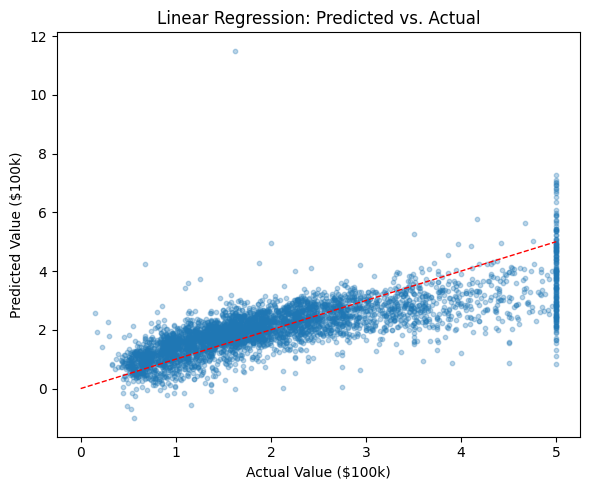

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error

# 1. Load data
dataset = fetch_california_housing()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='MedianHouseValue')

# 2. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# 3. Define the model pipeline
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])

# 4. Train
model.fit(X_train, y_train)

# 5. Evaluate on test set
y_pred = model.predict(X_test)
print(f"Test R²:  {model.score(X_test, y_test):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.3f} ($100k)")

# 6. Cross-validate for a stable estimate
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
print(f"CV R²: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

# 7. Visualize predictions vs. actual values
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=1)  # perfect prediction line
plt.xlabel('Actual Value ($100k)')
plt.ylabel('Predicted Value ($100k)')
plt.title('Linear Regression: Predicted vs. Actual')
plt.tight_layout()
plt.show()
